$\Large\textbf{BBP Phase Transition for an Extensive Number of Outliers}$

$\textbf{Authors: Niklas Forner, Alexander Maloney, Bernd Rosenow}$

Imports and Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import ortho_group

In [2]:
def MP_law_EV(x_ev, dim_ratio, sigma2 = 1):
    """
    x_ev: array (eigenvalue variable)
    dim_ratio: scalar (dimension ratio)
    sigma2: scalar (variance, squared value already)
    
    output: array (MP law for eigenvalues)
    """
    # Bulk boundaries and step function (zero outside boundaries).
    boundary_left = sigma2 * (1 - 1/np.sqrt(dim_ratio))**2
    boundary_right = sigma2 * (1 + 1/np.sqrt(dim_ratio))**2
    cases = np.heaviside(x_ev - boundary_left, 0) * np.heaviside(boundary_right - x_ev, 0)
    
    return np.sqrt(np.abs((boundary_right - x_ev) * (x_ev - boundary_left))) / (2 * np.pi * x_ev * sigma2) * dim_ratio * cases


# Create a random matrix of given dimensions with a set of variances.
def get_matrix(q, A, variances):
    """
    Creates a rectangular matrix with random entries, drawn according to variances.
    
    q: scalar (column dimension)
    A: scalar (dimension ratio)
    variances: either 1D array with q entries or 2D array in the form of a histogram (variance values and multiplicities)
    
    output: 2D array (random matrix where each row is independent and each j-th column is drawn according to the j-th variance)
    """
    # Create array of q variances from a histogram if not already in that form.
    length = len(np.shape(variances))      
    if length == 2: 
        mults = np.trim_zeros(variances[1]) # multiplicities in second array
        variances = np.repeat(variances[0][0:len(mults)], mults) # actual variance values in first array
    
    elif length != 1:
        print("Please insert a 1D or 2D array for the variances.")
        
    p = int(q*A) 
    
    # Create columns of matrix by drawing elements from normal distributions with given variances.
    my_scale = np.vstack([np.sqrt(variances/p)]*p) # p rows of q deviations (= variance square-root)
    my_size = [p, q] # draw p vectors of size q
        
    return np.random.default_rng().normal(loc=0, scale=my_scale, size=my_size) # matrix of dim. p x q (rows are drawn vectors)


def signal_matrix(q, A, signal_SVs):
    """
    Creates a rectangular matrix with the signal singular values on the diagonal.
    """
    p = int(q*A)
    mat = np.zeros((p, q))
    for i in range(len(signal_SVs)):
        mat[i, i] = signal_SVs[i]
    return mat


# Spectrum from Green function
def PDF_from_Green(G_vals, make_positive = False):
    """
    Turns Green function values into probability density values.
    
    G_vals: array (Green function values)
    
    output: array (spectral density P(x))
    """
    if make_positive:
        return np.abs(np.imag(G_vals)) / np.pi
    else:
        return - np.imag(G_vals) / np.pi
    

# Exact Green function
def poly_constants(z, sigma, A, rank_ratio, theta):
    """
    Determines the constants A-E of the quartic polynomial.
    """
    poly_A = z**2 * sigma**6 / A**3
    poly_B = sigma**4 / A**2 * (2 * z * sigma**2 * (1 - 1/A) - 3 * z**2)
    poly_C = sigma**2 / A * (3 * z**2 - z * theta**2 + sigma**4 * (1 - 1/A)**2 - 4 * z * sigma**2 * (1 - 1/A) + z * sigma**2 / A)
    poly_D = - theta**2 * (sigma**2 * (1 - 1/A) - z) + 2 * z *sigma**2 * (1 - 1/A) - sigma**4 * (1 - 1/A)**2 - z**2 + sigma**4 / A * (1 - 1/A) - 2 * z * sigma**2 / A 
    poly_E = z - sigma**2 * (1 - 1/A) - (1 - rank_ratio) * theta**2
    
    return [poly_A, poly_B, poly_C, poly_D, poly_E]


def poly_solutions(poly_A, poly_B, poly_C, poly_D, poly_E):
    """
    Calculates the four solutions of the quartic polynomial.
    """
    a = - 3 * poly_B**2 / (8 * poly_A**2) + poly_C / poly_A
    b = poly_B**3 / (8 * poly_A**3) - poly_B * poly_C / (2 * poly_A**2) + poly_D / poly_A
    c = - 3 * poly_B**4 / (256 * poly_A**4) + poly_C * poly_B**2 / (16 * poly_A**3) - poly_B * poly_D / (4 * poly_A**2) + poly_E / poly_A
    
    m = - a**2 / 12 - c
    n = - a**3 / 108 + a * c / 3 - b**2 / 8
    
    unit_root = -1/2 + np.sqrt(3)/2 *1j
    
    y = a / 6 + np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3)) - m / 3 / np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3))
#     y = a / 6 + unit_root * np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3)) - unit_root * m / 3 / np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3))
#     y = a / 6 + unit_root**2 * np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3)) - unit_root**2 * m / 3 / np.power(- n / 2 + np.sqrt(n**2 / 4 + m**3 / 27), (1/3))

    G_1 = ( - np.sqrt(2 * y - a) + np.sqrt(- 2 * y - a + 2 * b / np.sqrt(2 * y - a)) ) / 2 - poly_B / (4 * poly_A)
    G_2 = ( - np.sqrt(2 * y - a) - np.sqrt(- 2 * y - a + 2 * b / np.sqrt(2 * y - a)) ) / 2 - poly_B / (4 * poly_A)
    G_3 = ( + np.sqrt(2 * y - a) + np.sqrt(- 2 * y - a - 2 * b / np.sqrt(2 * y - a)) ) / 2 - poly_B / (4 * poly_A)
    G_4 = ( + np.sqrt(2 * y - a) - np.sqrt(- 2 * y - a - 2 * b / np.sqrt(2 * y - a)) ) / 2 - poly_B / (4 * poly_A)
    
    return np.array([G_1, G_2, G_3, G_4])



# Discriminant and Spectrum Roots
def discriminant_fast(z, sigma, A, rank_ratio, theta):
    """
    Calculates the discriminant of the quartic polynomial.
    """
    poly_A = z**2 * sigma**6 / A**3
    poly_B = sigma**4 / A**2 * (2 * z * sigma**2 * (1 - 1/A) - 3 * z**2)
    poly_C = sigma**2 / A * (3 * z**2 - z * theta**2 + sigma**4 * (1 - 1/A)**2 - 4 * z * sigma**2 * (1 - 1/A) + z * sigma**2 / A)
    poly_D = - theta**2 * (sigma**2 * (1 - 1/A) - z) + 2 * z *sigma**2 * (1 - 1/A) - sigma**4 * (1 - 1/A)**2 - z**2 + sigma**4 / A * (1 - 1/A) - 2 * z * sigma**2 / A 
    poly_E = z - sigma**2 * (1 - 1/A) - (1 - rank_ratio) * theta**2
    
    term_1 = 256 * poly_A**3 * poly_E**3 - 192 * poly_A**2 * poly_B * poly_D * poly_E**2 - 128 * poly_A**2 * poly_C**2 * poly_E**2 + 144 * poly_A**2 * poly_C * poly_D**2 * poly_E
    term_2 = - 27 * poly_A**2 * poly_D**4 + 144 * poly_A * poly_B**2 * poly_C * poly_E**2 - 6 * poly_A * poly_B**2 * poly_D**2 * poly_E - 80 * poly_A * poly_B * poly_C**2 * poly_D * poly_E
    term_3 = 18 * poly_A * poly_B * poly_C * poly_D**3 + 16 * poly_A * poly_C**4 * poly_E - 4 * poly_A * poly_C**3 * poly_D**2 - 27 * poly_B**4 * poly_E**2 + 18 * poly_B**3 * poly_C * poly_D * poly_E
    term_4 = - 4 * poly_B**3 * poly_D**3 - 4 * poly_B**2 * poly_C**3 * poly_E + poly_B**2 * poly_C**2 * poly_D**2
    
    return term_1 + term_2 + term_3 + term_4


def roots_from_data_fast(x, y):
    """
    Determines the roots from a discrete array (either when y = 0 exactly or when y changes its sign).
    """
    x_array = np.array(x)
    y_array = np.array(y)
    
    actual_zeros = x_array[y_array == 0]
    
    signs = np.sign(y_array)
    flips = (signs[0:-1:] * signs[1::] < 0)
    proximity_zeros = x_array[0:-1:][flips] + np.diff(x_array)[flips] / 2
    
    return np.sort(np.unique(np.concatenate((actual_zeros, proximity_zeros))))


def upper_MP_bound_EV(sigma, A):
    """
    Calculates the upper boundary of the Marchenko-Pastur law (location of the phase transition in low-rank limit).
    """
    return sigma**2 * (1 + 1/np.sqrt(A))**2


def fullrank_endpoint(sigma, A):
    """
    Calculates the endpoint (full-rank limit) of the phase transition line for the phase diagram.
    """
    return sigma**2 / A * (1 + np.sqrt(A - 1))


def sqrt_0_radicand(z, sigma, A, rank_ratio, theta):
    """
    Calculates the radicand of the relevant square-root in the quartic polynomial's solution G (just the inside of the square-root)
    """
    poly_A = z**2 * sigma**6 / A**3
    poly_B = sigma**4 / A**2 * (2 * z * sigma**2 * (1 - 1/A) - 3 * z**2)
    poly_C = sigma**2 / A * (3 * z**2 - z * theta**2 + sigma**4 * (1 - 1/A)**2 - 4 * z * sigma**2 * (1 - 1/A) + z * sigma**2 / A)
    poly_D = - theta**2 * (sigma**2 * (1 - 1/A) - z) + 2 * z *sigma**2 * (1 - 1/A) - sigma**4 * (1 - 1/A)**2 - z**2 + sigma**4 / A * (1 - 1/A) - 2 * z * sigma**2 / A 
    poly_E = z - sigma**2 * (1 - 1/A) - (1 - rank_ratio) * theta**2
    
    a = - 3 * poly_B**2 / (8 * poly_A**2) + poly_C / poly_A
    b = poly_B**3 / (8 * poly_A**3) - poly_B * poly_C / (2 * poly_A**2) + poly_D / poly_A
    c = - 3 * poly_B**4 / (256 * poly_A**4) + poly_C * poly_B**2 / (16 * poly_A**3) - poly_B * poly_D / (4 * poly_A**2) + poly_E / poly_A
    
    m = - a**2 / 12 - c
    n = - a**3 / 108 + a * c / 3 - b**2 / 8
    
    return n**2 / 4 + m**3 / 27


def signal_for_first_inner_boundary_rad(theta_axis, EV_axis, sigma, A, rank_ratio):
    """
    Computes the spectral boundaries using the relevant radicand of the G solution 
    and returns the first theta value (smalles signal) for which there is an inner boundary.
    """
    previous_theta = 0
    
    for theta_single in theta_axis:
        rad = sqrt_0_radicand(EV_axis, sigma, A, rank_ratio, theta_single)
        root_set = roots_from_data_fast(EV_axis, rad)
        root_set = root_set[root_set < theta_single**2 + 4.2 * sigma**2 * (1 + 1/np.sqrt(A))**2] # no coincidental high values
                
        if A == 1:
            root_set = np.concatenate((np.zeros(1), root_set)) # put 0 as the lower boundary for A = 1
        
        root_set = np.unique(root_set)
                    
        if len(root_set) == 4: 
            return (theta_single**2, theta_single**2 - previous_theta**2, root_set)
        
        previous_theta = theta_single
        
    return (np.NaN, np.NaN, np.NaN)


def log_line(x, exponent, constant):
    """
    Calculates a simple exponentiated version of an array for an affine line on a log scale.
    """
    return constant * x**exponent


# Pre-defined Colors
my_colors_exp = ["#1f77b4", "#ff7f0e", "#2ca02c"]
my_colors_theo = ["cyan", "maroon", "lightgreen"]

Splitting of the Spectrum

Time for SV calculation (A = 2, q = 1000) = 5.93915319442749 s
Time for SV calculation (A = 2, q = 1000) = 5.804275751113892 s
Time for SV calculation (A = 2, q = 1000) = 5.73490047454834 s


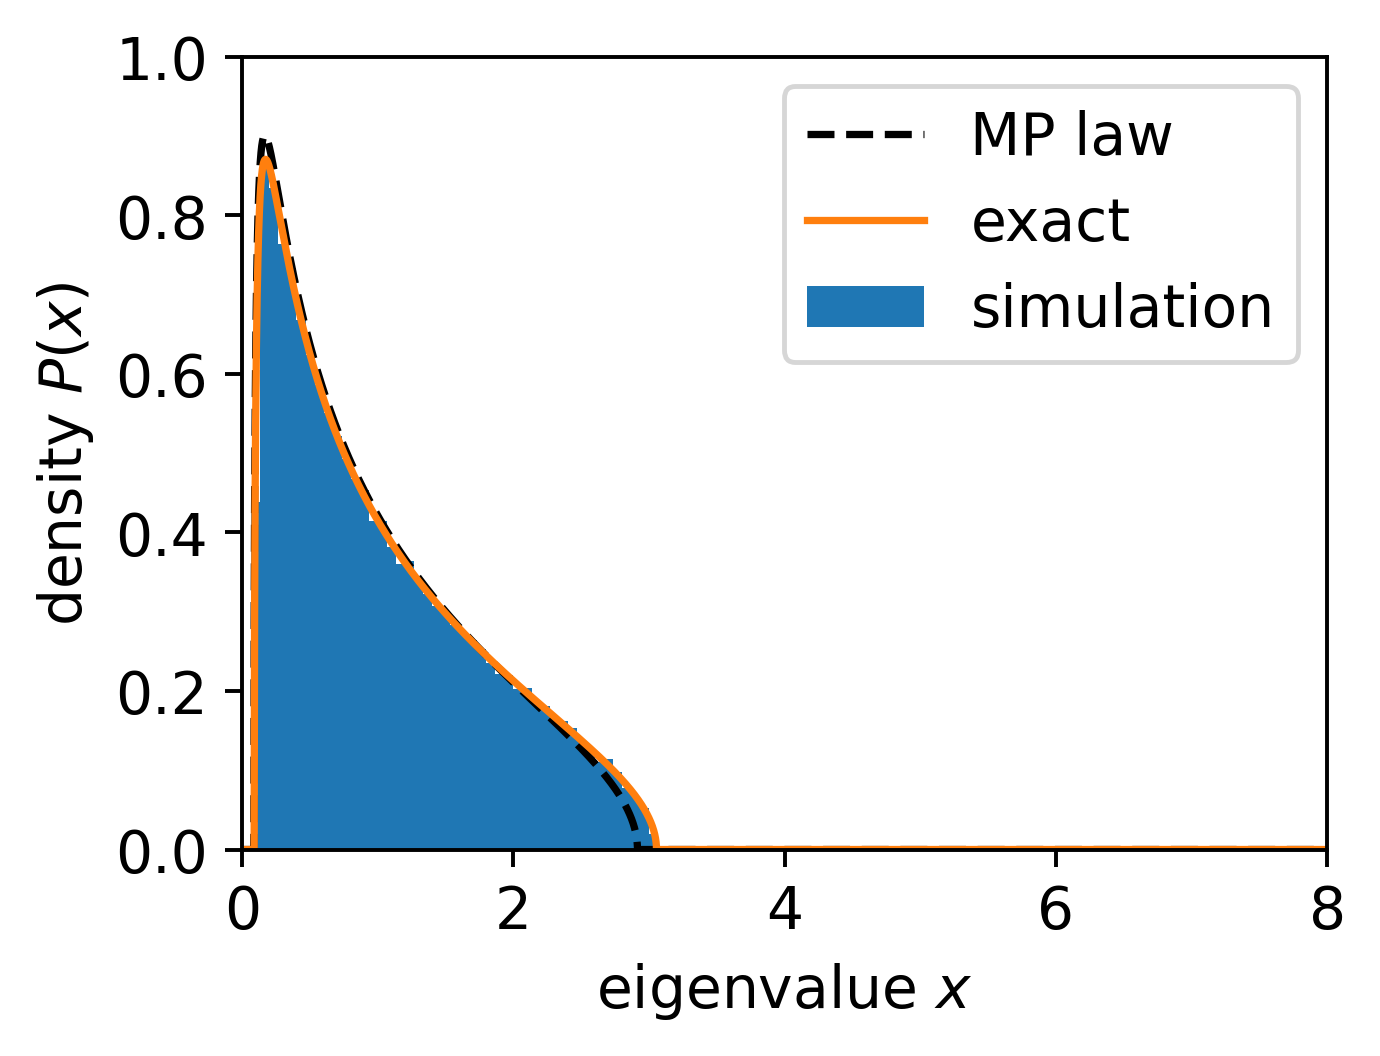

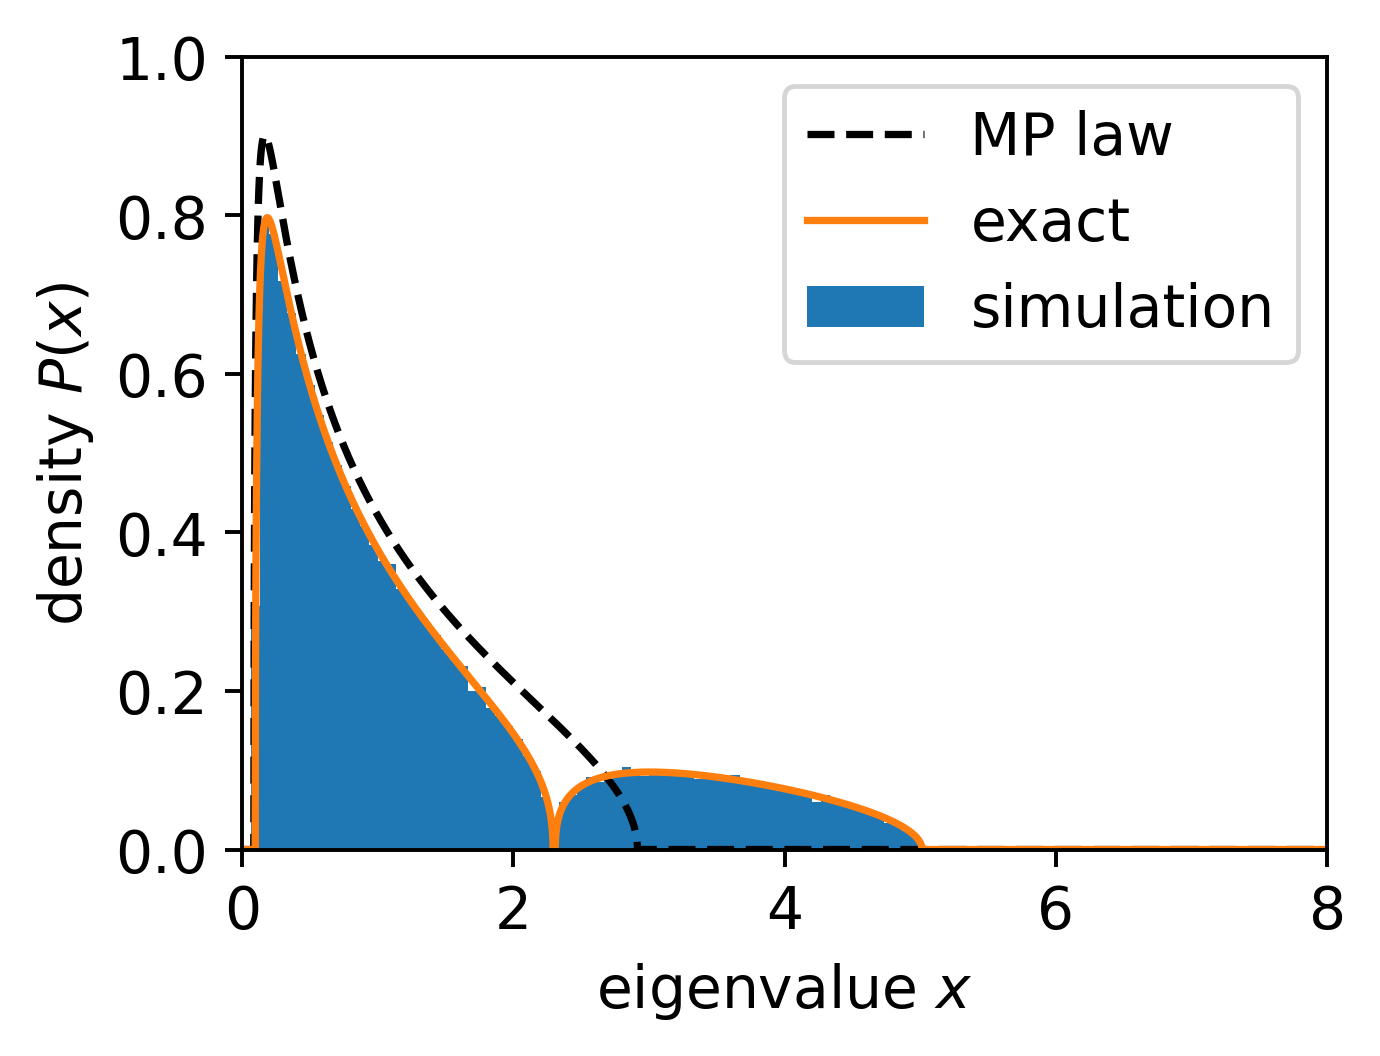

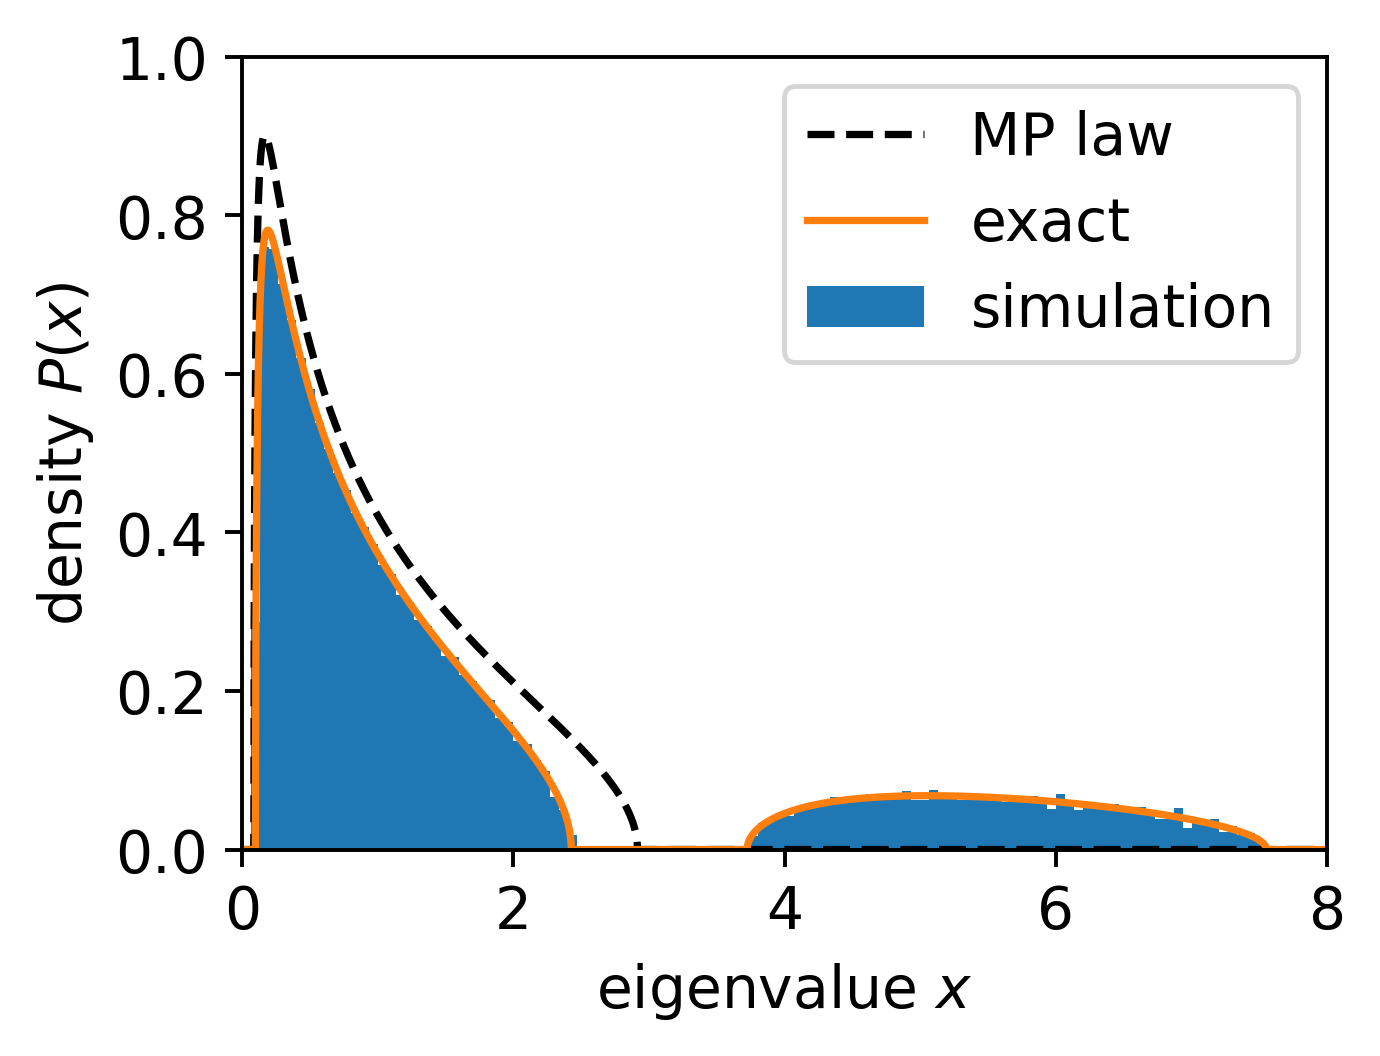

In [3]:
sigma = 1
A = 2
rank_ratio = 0.2
theta_cases = np.sqrt(np.array([0.2, 1.9, 4])) # np.array([np.sqrt(1), np.sqrt(2.75), np.sqrt(4.5)])
EV_axis = np.linspace(0, 11, 10**4 + 1)[1::]

# Exact
Green_theo = [poly_solutions(*poly_constants(EV_axis + 1e-10 * 1j, sigma, A, rank_ratio, theta)) for theta in theta_cases]
PDF_theo = [PDF_from_Green(Green_theo[i]) for i in range(len(theta_cases))]
PDF_theo = [np.sum(np.maximum(0, PDF_theo[i]), axis=0) for i in range(len(theta_cases))]

# Experiment
dim_q = 1000
num_of_runs = 10
histo_q_collection = [0]*len(theta_cases)

for i in range(len(theta_cases)):
    signal_SVs = np.ones(int(rank_ratio * dim_q)) * theta_cases[i] 
    
    start = time.time()
    exp_SV_q_collection = np.empty((num_of_runs, dim_q)) 
    var_samples_q = np.ones(dim_q)
    for j in range(num_of_runs):
        exp_SV_q_collection[j] = np.linalg.svd(get_matrix(dim_q, A, var_samples_q) + signal_matrix(dim_q, A, signal_SVs), compute_uv=False)
    end = time.time()
    print(f"Time for SV calculation (A = {A}, q = {dim_q}) =", end - start, "s")
    
    exp_EV_q_collection = exp_SV_q_collection.flatten()**2 # squaring gives eigenvalues of sample covariance matrix

    histo_q_collection[i] = np.histogram(exp_EV_q_collection, bins = np.linspace(0, 10, 151), density=True) # bins = np.linspace(np.min(exp_EV_q_collection), np.max(exp_EV_q_collection), 10**2)
    


for i in range(len(theta_cases)): 
    plt.figure(figsize=(4,3), dpi=350)
    plt.rcParams.update({'font.size': 12})
    plt.plot(EV_axis, MP_law_EV(EV_axis, A, sigma2 = sigma**2), "--", color = "black", label = r"MP law")   
    plt.bar(histo_q_collection[i][1][:-1:], histo_q_collection[i][0], color = my_colors_exp[0], align = "edge", width = np.diff(histo_q_collection[i][1]), label = r"simulation") # "center"
    plt.plot(EV_axis, PDF_theo[i], "-", color = my_colors_exp[1], label = f"exact")   
    plt.xlim([0, 8])
    plt.ylim([0, 1])
    plt.xlabel(r"eigenvalue $x$")
    plt.ylabel(r"density $P(x)$")
    plt.xscale("linear")
    plt.yscale("linear")
#     plt.title(f"$A = {my_A[i]}$")
    plt.legend()
plt.show()

plt.rcParams.update({'font.size': 10})

Boundaries Depending on Signal

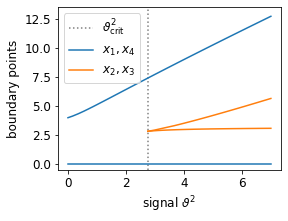

In [4]:
A = 1
sigma = 1
rank_ratio = 0.2
max_theta = np.sqrt(9)
my_theta_axis = np.sqrt(np.linspace(0, max_theta**2 -2, 10**3 +1))[1::]
my_EV_axis = np.linspace(0, max_theta**2 + 10, 10**4 + 1)[1::]
my_discriminant_vals = [sqrt_0_radicand(my_EV_axis, sigma, A, rank_ratio, theta_single) for theta_single in my_theta_axis] # rescaled discriminant values
my_roots = [roots_from_data_fast(my_EV_axis, _) for _ in my_discriminant_vals]

for i in range(len(my_roots)):
    my_roots[i] = np.concatenate((np.zeros(1), np.array([np.NaN]*(3-len(my_roots[i]))), my_roots[i]))
    
crit_signal = signal_for_first_inner_boundary_rad(my_theta_axis, my_EV_axis, sigma, A, rank_ratio)[0]
    
my_roots = np.array(my_roots)
my_theta2_plot_axis = my_theta_axis**2

plt.figure(figsize=(4,3))
plt.rcParams.update({'font.size': 12})
plt.axvline(crit_signal, ls = ":", color = "grey", label = r"$\vartheta^2_{\mathrm{crit}}$")
plt.plot(my_theta2_plot_axis, my_roots[:, 0], "-", color = my_colors_exp[0], label = f"$x_{1}, x_{4}$")
plt.plot(my_theta2_plot_axis, my_roots[:, 1], "-", color = my_colors_exp[1], label = f"$x_{2}, x_{3}$")
plt.plot(my_theta2_plot_axis, my_roots[:, 2], "-", color = my_colors_exp[1])
plt.plot(my_theta2_plot_axis, my_roots[:, 3], "-", color = my_colors_exp[0])
plt.ylim([-0.5, 13.5])
plt.xlabel(r"signal $\vartheta^2$")
plt.ylabel(r"boundary points")
plt.xscale("linear")
plt.yscale("linear")
plt.legend()
plt.show()

Phase Transition

2.0 % done.
4.0 % done.
7.0 % done.
9.0 % done.
11.0 % done.
13.0 % done.
15.0 % done.
17.0 % done.
20.0 % done.
22.0 % done.
24.0 % done.
26.0 % done.
28.0 % done.
30.0 % done.
33.0 % done.
35.0 % done.
37.0 % done.
39.0 % done.
41.0 % done.
43.0 % done.
46.0 % done.
48.0 % done.
50.0 % done.
52.0 % done.
54.0 % done.
57.0 % done.
59.0 % done.
61.0 % done.
63.0 % done.
65.0 % done.
67.0 % done.
70.0 % done.
72.0 % done.
74.0 % done.
76.0 % done.
78.0 % done.
80.0 % done.
83.0 % done.
85.0 % done.
87.0 % done.
89.0 % done.
91.0 % done.
93.0 % done.
96.0 % done.
98.0 % done.
100.0 % done.
[1.00000000e-06 2.88539981e-06 8.32553207e-06 2.40224887e-05
 6.93144843e-05 2.00000000e-04 5.77079962e-04 1.66510641e-03
 4.80449774e-03 1.38628969e-02 4.00000000e-02 7.68000000e-02
 1.13600000e-01 1.50400000e-01 1.87200000e-01 2.24000000e-01
 2.60800000e-01 2.97600000e-01 3.34400000e-01 3.71200000e-01
 4.08000000e-01 4.44800000e-01 4.81600000e-01 5.18400000e-01
 5.55200000e-01 5.92000000e-01 6.288000

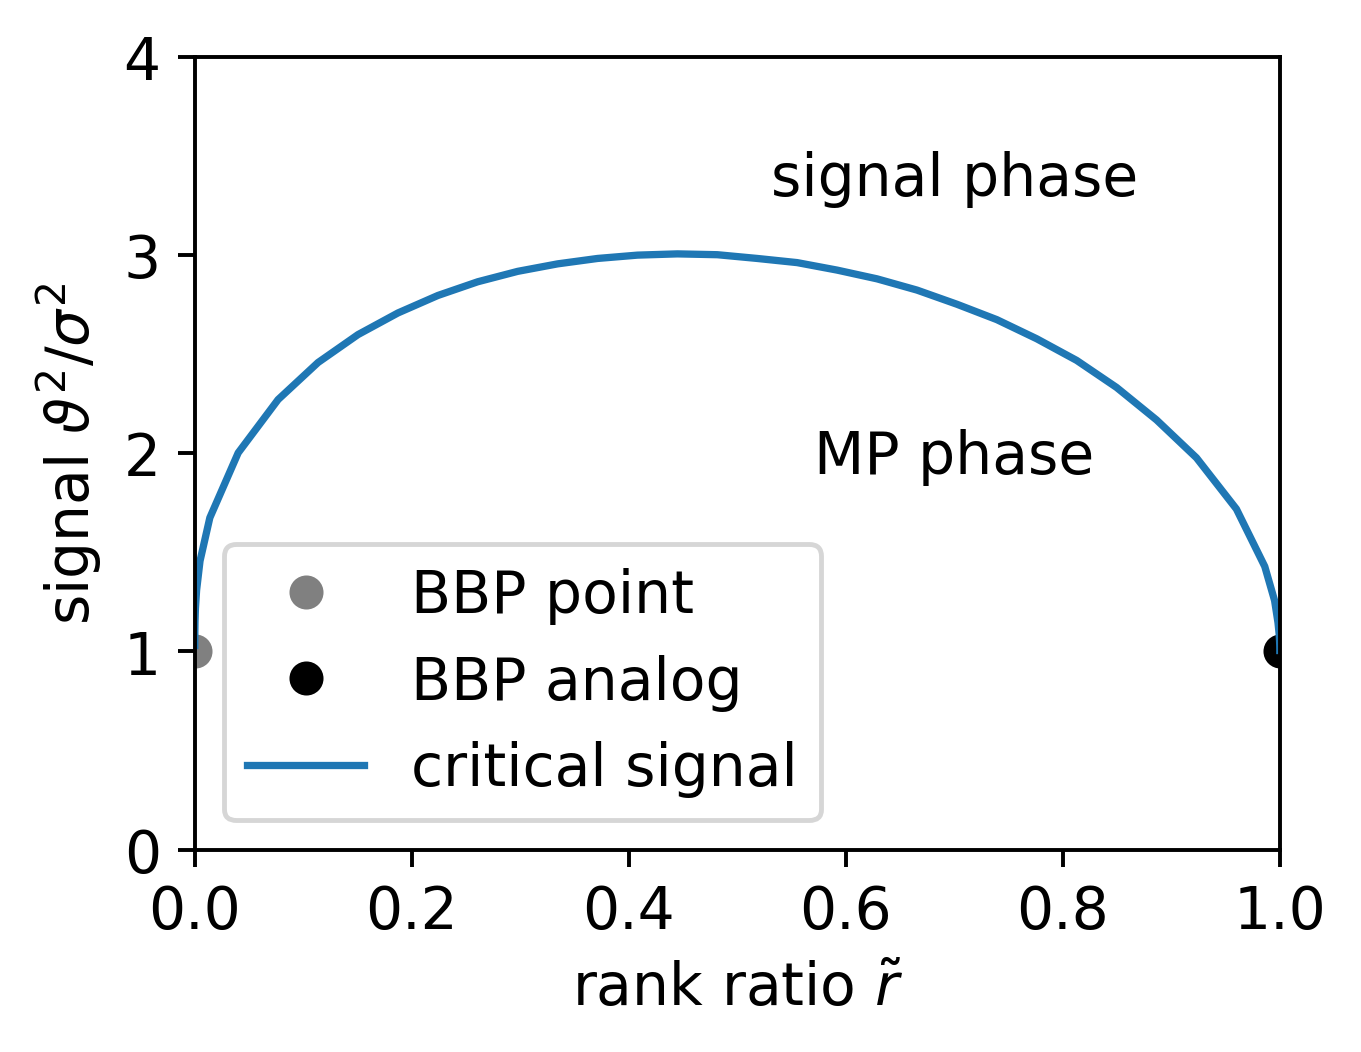

In [6]:
# ETA = 10 min
A = 1
sigma = 1

# rank_ratio_test = np.concatenate((np.logspace(-6, np.log10(0.025), 10 + 1)[:-1:], np.linspace(0, 1, 20 + 1)[1:-1:], 1 - np.logspace(-6, np.log10(0.025), 10 + 1)[::-1]))
rank_ratio_test = np.logspace(-6, np.log10(0.04), 10 + 1)
rank_ratio_test = np.concatenate((rank_ratio_test, np.linspace(rank_ratio_test[-1], 1 - rank_ratio_test[-1], 25 + 1)[1:-1]))
rank_ratio_test = np.concatenate((rank_ratio_test, 1 - np.logspace(-6, np.log10(0.04), 10 + 1)[::-1]))

max_theta = np.sqrt(9)
EV_axis = np.logspace(-14, -3, 10**4 + 1)
EV_axis = np.concatenate((EV_axis, np.linspace(EV_axis[-1], max_theta**2 + 10 * sigma**2, 10**5 + 1)[1::])) # make sure outer boundaries are included
theta_axis = np.sqrt(np.linspace(sigma**2 / np.sqrt(A), 3.1 * sigma**2 / np.sqrt(A), 10**3 +1))[1::] 


data = {"rank ratio": rank_ratio_test}

roots_r = [0]*len(rank_ratio_test)
errors_r = [0]*len(rank_ratio_test)
all_intersections_r = [0]*len(rank_ratio_test)

for ind in range(len(rank_ratio_test)):
    all_intersections_r[ind], errors_r[ind], roots_r[ind] = signal_for_first_inner_boundary_rad(theta_axis, EV_axis, sigma, A, rank_ratio_test[ind])
    print(np.round(100 * (ind + 1) / len(rank_ratio_test), 0), "% done.")
    
    data[f"values {A}"] = all_intersections_r
    data[f"errors {A}"] = errors_r
    
print(rank_ratio_test)
print(all_intersections_r)


yerr_low = errors_r
yerr = [yerr_low, [0]*len(yerr_low)]

plt.figure(figsize=(4,3), dpi=350)
# plt.rcParams.update({'font.size': 12})
plt.plot([0], [np.sqrt(A)], "o", color = "grey", label = "BBP point") # r"$\vartheta^2_{\mathrm{crit}} / \sigma^2$ (BBP)"
plt.plot([1], [np.sqrt(A)], "o", color = "black", label = "BBP analog") # r"$\vartheta^2_{\mathrm{crit}} / \sigma^2 \ (\tilde{r} \to 1)$"
plt.plot(rank_ratio_test, np.array(all_intersections_r) / sigma**2, "-", label = "critical signal") # r"$\vartheta^2_{\mathrm{crit}} / \sigma^2$"
# plt.errorbar(rank_ratio_test, all_intersections_r, yerr = errors_r, ls = "-", marker = ".", label = r"$\vartheta^2_{\mathrm{crit}}$")
plt.text(0.7, 3.3, "signal phase", horizontalalignment = "center")
plt.text(0.7, 1.9, "MP phase", horizontalalignment = "center")
plt.xlim([0, 1]) # [-4e-2, 1+4e-2]
plt.ylim([0, 4])
plt.xlabel(r"rank ratio $\tilde{r}$")
plt.ylabel(r"signal $\vartheta^2 / \sigma^2$")
plt.xscale("linear")
plt.yscale("linear")
plt.legend()
plt.show()

In [13]:
# ETA = 1 h
my_A = [1, 2, 10]
sigma = 1

# rank_ratio_test = np.concatenate((np.logspace(-6, np.log10(0.025), 10 + 1)[:-1:], np.linspace(0, 1, 20 + 1)[1:-1:], 1 - np.logspace(-6, np.log10(0.025), 10 + 1)[::-1]))
rank_ratio_test = np.logspace(-6, np.log10(0.04), 10 + 1)
rank_ratio_test = np.concatenate((rank_ratio_test, np.linspace(rank_ratio_test[-1], 1 - rank_ratio_test[-1], 25 + 1)[1:-1]))
rank_ratio_test = np.concatenate((rank_ratio_test, 1 - np.logspace(-6, np.log10(0.04), 10 + 1)[::-1]))
print(rank_ratio_test)

max_theta = np.sqrt(9)


data = {"rank ratio": rank_ratio_test}

for A in my_A: # my_A[1:]
    theta_axis = np.sqrt(np.linspace(0.9*sigma**2 / np.sqrt(A), 3 / np.sqrt(A), 10**3 +1))[1::] 
    
    if A == 1:
        EV_axis = np.logspace(-14, -3, 10**4 + 1)
        EV_axis = np.concatenate((EV_axis, np.linspace(EV_axis[-1], max_theta**2 + 10 * sigma**2, 10**5 + 1)[1::])) # make sure outer boundaries are included
    else:
        EV_axis = np.linspace(0, max_theta**2 + 1 * sigma**2, 1 * 10**5 + 1)[1::]

    roots_r = [0]*len(rank_ratio_test)
    errors_r = np.empty(len(rank_ratio_test))
    all_intersections_r = np.empty(len(rank_ratio_test))

    for ind in range(len(rank_ratio_test)):
#         Delta = min(rank_ratio_test[ind]**(1/4), 0.5)
#         EV_axis = np.concatenate((np.linspace(0, upper_MP_bound_EV(sigma, A) - Delta, 10**4 + 1)[1::], np.linspace(upper_MP_bound_EV(sigma, A) - Delta, upper_MP_bound_EV(sigma, A) + Delta, 5*10**5 + 1)[1::], np.linspace(upper_MP_bound_EV(sigma, A) + Delta, max_theta**2 + 1, 10**4 + 1)[1::]))

        all_intersections_r[ind], errors_r[ind], roots_r[ind] = signal_for_first_inner_boundary_rad(theta_axis, EV_axis, sigma, A, rank_ratio_test[ind])
        print(np.round(100 * (ind + 1) / len(rank_ratio_test), 0), "% done.")

        data[f"values {A}"] = (all_intersections_r - errors_r / 2) / sigma**2
        data[f"errors {A}"] = (errors_r / 2) / sigma**2

    print(all_intersections_r)

[1.00000000e-06 2.88539981e-06 8.32553207e-06 2.40224887e-05
 6.93144843e-05 2.00000000e-04 5.77079962e-04 1.66510641e-03
 4.80449774e-03 1.38628969e-02 4.00000000e-02 7.68000000e-02
 1.13600000e-01 1.50400000e-01 1.87200000e-01 2.24000000e-01
 2.60800000e-01 2.97600000e-01 3.34400000e-01 3.71200000e-01
 4.08000000e-01 4.44800000e-01 4.81600000e-01 5.18400000e-01
 5.55200000e-01 5.92000000e-01 6.28800000e-01 6.65600000e-01
 7.02400000e-01 7.39200000e-01 7.76000000e-01 8.12800000e-01
 8.49600000e-01 8.86400000e-01 9.23200000e-01 9.60000000e-01
 9.86137103e-01 9.95195502e-01 9.98334894e-01 9.99422920e-01
 9.99800000e-01 9.99930686e-01 9.99975978e-01 9.99991674e-01
 9.99997115e-01 9.99999000e-01]
2.0 % done.
4.0 % done.
7.0 % done.
9.0 % done.
11.0 % done.
13.0 % done.
15.0 % done.
17.0 % done.
20.0 % done.
22.0 % done.
24.0 % done.
26.0 % done.
28.0 % done.
30.0 % done.
33.0 % done.
35.0 % done.
37.0 % done.
39.0 % done.
41.0 % done.
43.0 % done.
46.0 % done.
48.0 % done.
50.0 % done.
52

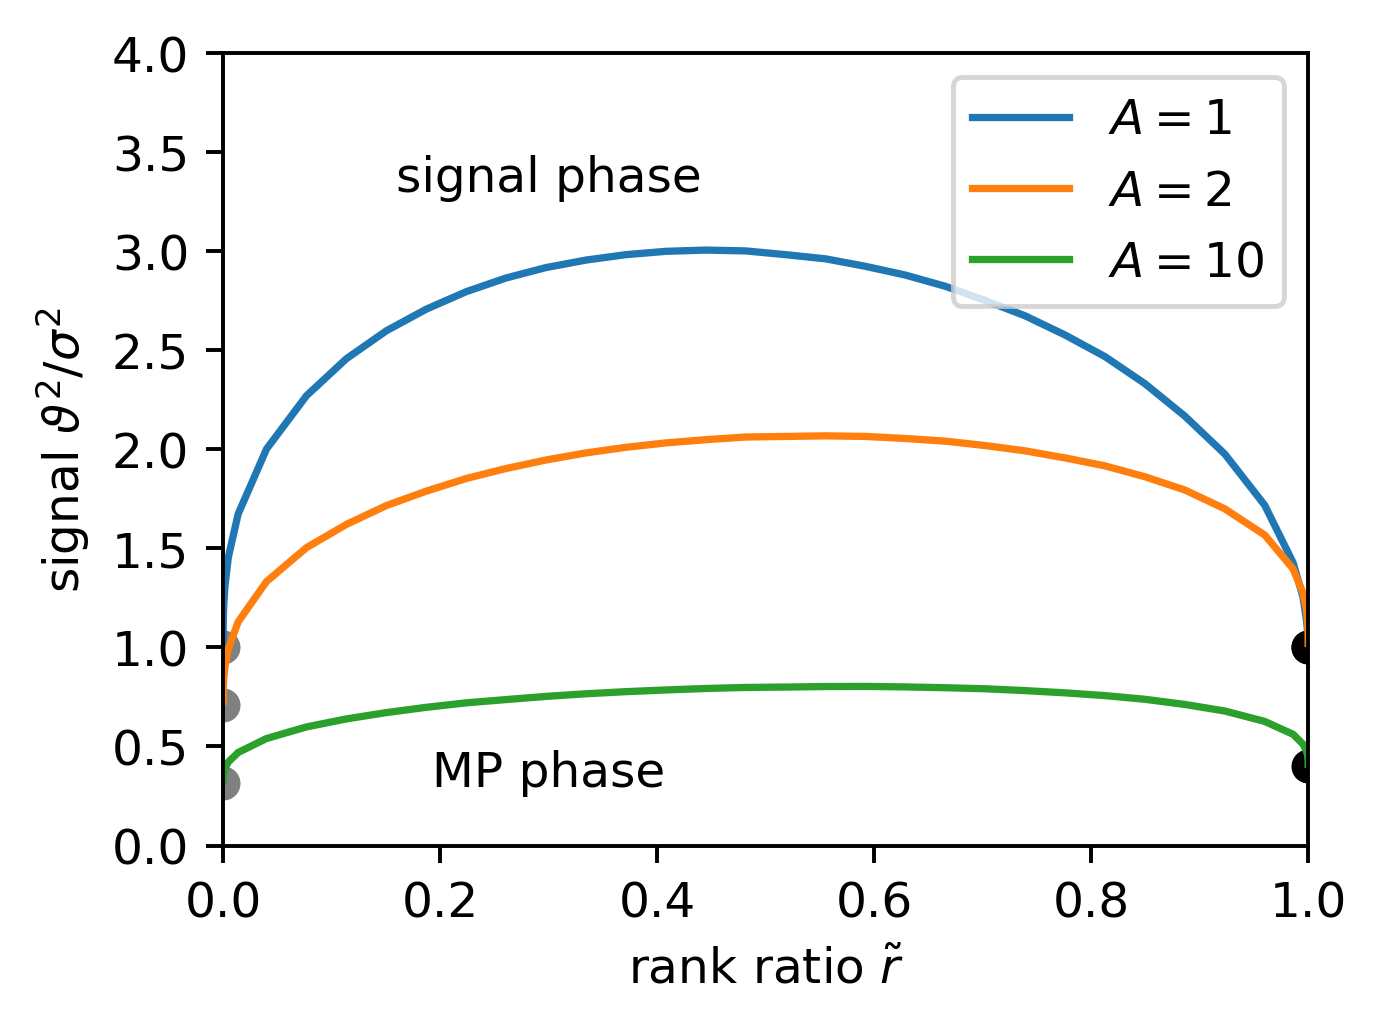

In [20]:
plt.figure(figsize=(4,3), dpi=350)
# plt.rcParams.update({'font.size': 12})

for A in my_A:
    plt.plot([0], [1/np.sqrt(A)], "o", color = "grey") # , label = "BBP point"
    plt.plot([1], [fullrank_endpoint(sigma, A)], "o", color = "black") # , label = "BBP analog"
    plt.plot(rank_ratio_test, data[f"values {A}"], "-", label = f"$A = {A}$")
#     plt.errorbar(rank_ratio_test, data[f"values {A}"], yerr = data[f"errors {A}"], ls = "-", marker = ".", label = f"$A = {A}$")
plt.text(0.3, 3.3, "signal phase", horizontalalignment = "center")
plt.text(0.3, 0.3, "MP phase", horizontalalignment = "center")
plt.xlim([0, 1]) 
plt.ylim([0, 4])
plt.xlabel(r"rank ratio $\tilde{r}$")
plt.ylabel(r"signal $\vartheta^2 / \sigma^2$")
plt.xscale("linear")
plt.yscale("linear")
plt.legend(loc = "upper right")
plt.show()

Scaling Law

In [7]:
# ETA = 25 min
sigma = 1
# rank_ratio_test = np.logspace(-9, -1, 9)
rank_ratio_test = np.logspace(-6, -1, 11)
max_theta = np.sqrt(9)

data = {"rank ratio": rank_ratio_test}

my_A = [1, 2, 10]
crit_signals_of_r_A = {}
for A in my_A:      
    theta_axis = np.sqrt(np.linspace(0.9*sigma**2 / np.sqrt(A), 3 / np.sqrt(A), 10**3 +1))[1::] # np.sqrt(np.linspace(sigma**2 / np.sqrt(A), 3 / np.sqrt(A), 10**3 +1))

#     EV_axis = np.linspace(0, max_theta**2, 10**5 + 1)[1::]
    
    roots_r = [0]*len(rank_ratio_test)
    errors_r = [0]*len(rank_ratio_test)
    all_intersections_r = [0]*len(rank_ratio_test)

    for ind in range(len(rank_ratio_test)):
        Delta = min(rank_ratio_test[ind]**(1/4), 0.5)
#         print(Delta)
        EV_axis = np.concatenate((np.linspace(0, upper_MP_bound_EV(sigma, A) - Delta, 10**4 + 1)[1::], np.linspace(upper_MP_bound_EV(sigma, A) - Delta, upper_MP_bound_EV(sigma, A) + Delta, 5*10**5 + 1)[1::], np.linspace(upper_MP_bound_EV(sigma, A) + Delta, max_theta**2 + 1, 10**4 + 1)[1::]))

        all_intersections_r[ind], errors_r[ind], roots_r[ind] = signal_for_first_inner_boundary_rad(theta_axis, EV_axis, sigma, A, rank_ratio_test[ind])
        print(np.round(100 * (ind + 1) / len(rank_ratio_test), 0), "% done.")
        
        print("theta^2 =", all_intersections_r[ind], "theta =", all_intersections_r[ind]**(1/2))
        print(roots_r[ind])
#         plt.figure()
#         plt.plot(EV_axis, sqrt_0_radicand(EV_axis, sigma, A, rank_ratio_test[ind], np.sqrt(all_intersections_r[ind])))
#         interval = roots_r[ind][2] - roots_r[ind][1]
#         mean = (roots_r[ind][2] + roots_r[ind][1]) / 2
#         plt.xlim([mean - interval*2, mean + interval*2])
#         plt.ylim(np.array([-1, 1]) * rank_ratio_test[ind]**(2.5))
#         plt.show()

    crit_signals_of_r_A[A] = (all_intersections_r, errors_r)
    data[f"values {A}"] = all_intersections_r
    data[f"errors {A}"] = errors_r
print("Done.")

9.0 % done.
theta^2 = 1.0260000000000002 theta = 1.012916580968048
[0.         3.99982968 3.99985371 4.00162256]
18.0 % done.
theta^2 = 1.0365 theta = 1.0180864403379508
[0.         3.99960538 3.99961769 4.00331074]
27.0 % done.
theta^2 = 1.0533000000000003 theta = 1.0263040485158383
[0.         3.99912803 3.99914243 4.00700823]
36.0 % done.
theta^2 = 1.0785 theta = 1.0385085459446157
[0.         3.99808312 3.99810442 4.01488105]
45.0 % done.
theta^2 = 1.1162999999999998 theta = 1.0565509926170151
[0.        3.9957762 3.9958138 4.031537 ]
55.0 % done.
theta^2 = 1.1729999999999998 theta = 1.0830512453249845
[0.         3.99060267 3.99066028 4.06639256]
64.0 % done.
theta^2 = 1.2570000000000001 theta = 1.121160113453917
[0.         3.97861334 3.97862046 4.13770107]
73.0 % done.
theta^2 = 1.3892999999999998 theta = 1.178685708745126
[0.         3.95131617 3.95133799 4.28583356]
82.0 % done.
theta^2 = 1.5951000000000002 theta = 1.2629726837901127
[0.         3.88667978 3.88672532 4.584786 

[1, 2, 10]
[[0.35079987 2.9901492 ]
 [0.35363099 1.90863039]
 [0.34379199 0.65818036]]


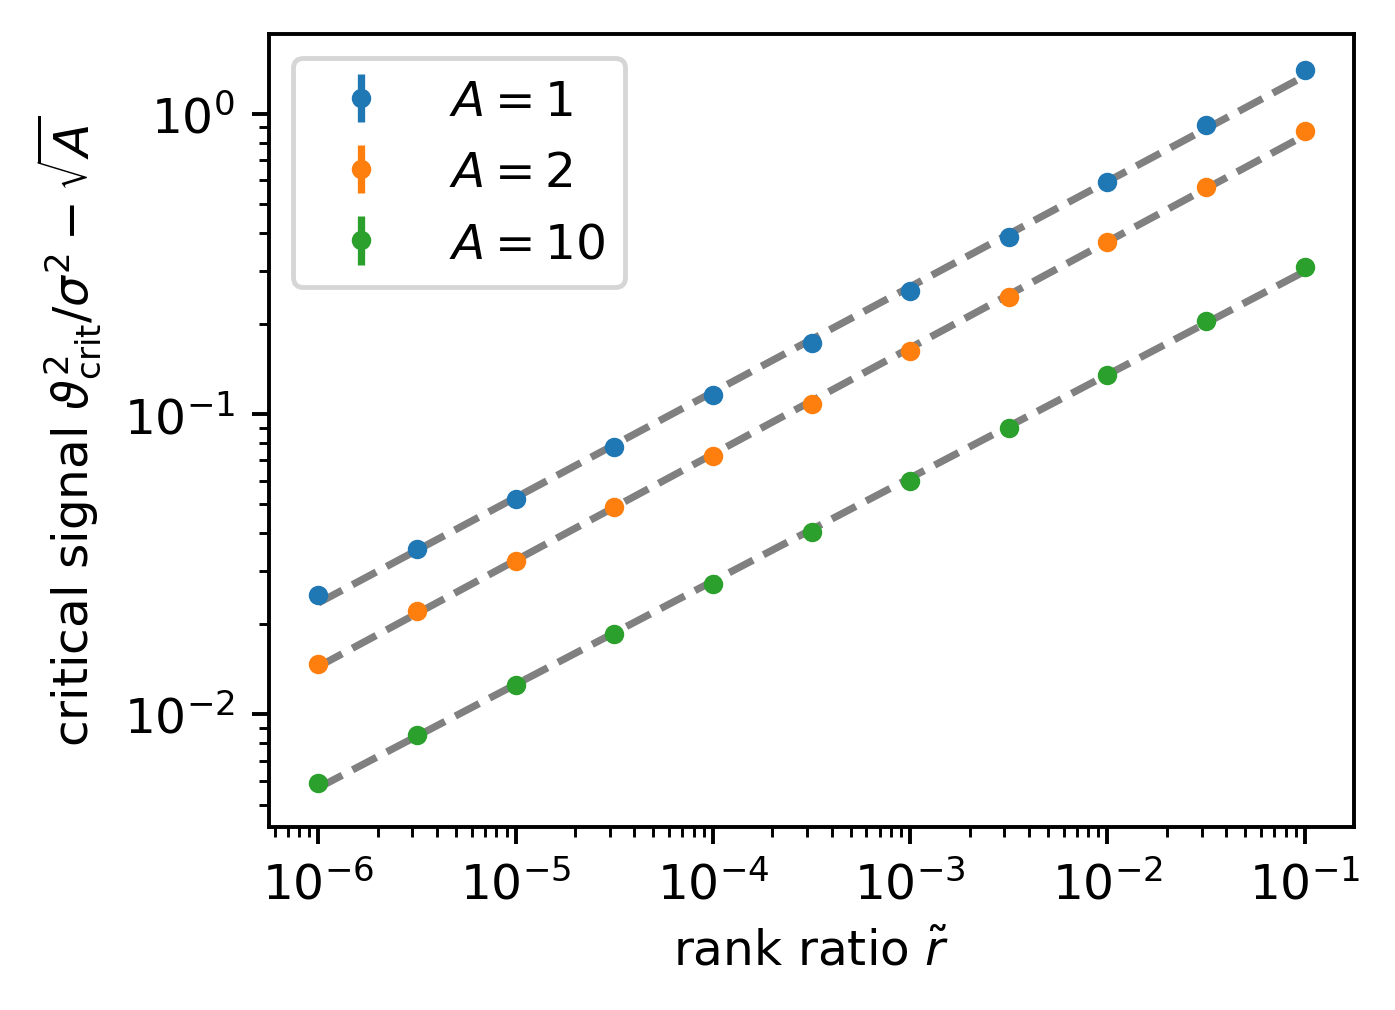

In [8]:
# finding out the slope and the multiplicative constant:

fit_axis_x = np.log10(rank_ratio_test)# [2:] # from four cells above
fit_axes_y = [np.log10((np.array(crit_signals_of_r_A[A][0]) - np.array(crit_signals_of_r_A[A][1])/2) / sigma**2 - 1/np.sqrt(A)) for A in my_A] # - sigma**2 / np.sqrt(A))[2:]

fit_params = np.zeros((len(my_A), 2))
for i in range(len(my_A)):
    slope, intercept = np.polyfit(fit_axis_x, fit_axes_y[i], 1) 
    fit_params[i][0] = slope # scaling exponent
    fit_params[i][1] = 10**(intercept) # multiplicative constant
    
print(my_A)
print(fit_params)


plt.figure(figsize=(4,3), dpi=350)
plt.rcParams.update({'font.size': 10})
for i in range(len(my_A)):
    plt.plot(10**fit_axis_x, log_line(10**fit_axis_x, fit_params[i][0], fit_params[i][1]), "--", color = "grey")
for A in my_A:
#     yerr_low = crit_signals_of_r_A[A][1]
#     yerr = (yerr_low, [0]*len(yerr_low))
    yerr = np.array(crit_signals_of_r_A[A][1]) / 2
    plt.errorbar(rank_ratio_test, (np.array(crit_signals_of_r_A[A][0]) - np.array(crit_signals_of_r_A[A][1])/2) / sigma**2 - 1/np.sqrt(A), yerr = yerr, ls = "", marker = ".", label = f"$A = {A}$")
plt.xlabel(r"rank ratio $\tilde{r}$")
plt.ylabel(r"critical signal $\vartheta^2_{\mathrm{crit}} / \sigma^2 - \sqrt{A}$")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

# USE THIS ONE

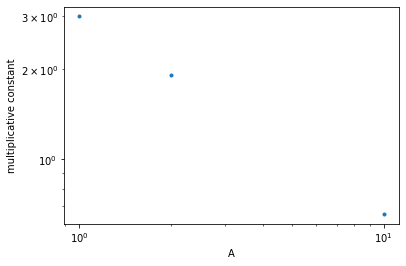

multplicative constant approximately (by fit): 2.999031728440331 $A^-0.658081346426174$


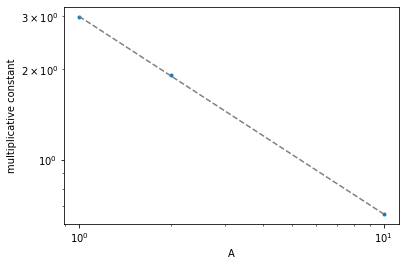

In [9]:
plt.loglog(my_A, fit_params[:,1], ".")
plt.xlabel("A")
plt.ylabel("multiplicative constant")
plt.show()

slope, intercept = np.polyfit(np.log10(np.array(my_A)), np.log10(fit_params[:,1]), 1) 
print("multplicative constant approximately (by fit):", 10**intercept, f"$A^{slope}$")

plt.figure()
plt.loglog(my_A, fit_params[:,1], ".")
plt.loglog(my_A, 10**intercept * np.array(my_A)**slope, "--", color = "grey")
plt.xlabel("A")
plt.ylabel("multiplicative constant")
plt.show()

Large Signals

In [10]:
def large_signal_Green(z, sigma, A, rank_ratio, theta):
    """
    Computes the approximation of the Green function in the large-signal regime.
    """
    pref = z - theta**2 - sigma**2 * (1 - 3/A)
    sqrt = np.sqrt(pref**2 - 8 * sigma**2 / A * (z - theta**2 - sigma**2 * (1 - 1/A) + rank_ratio * theta**2))
    G_plus = A/(4*z*sigma**2) * (pref + sqrt)
    G_minus = A/(4*z*sigma**2) * (pref - sqrt)
    
    return np.array([G_plus, G_minus])


def large_signal_PDF(x, sigma, A, rank_ratio, theta):   
    """
    Computes the approximation of the spectral probability density in the large-signal regime.
    """
    lim_up = theta**2 + sigma**2 * (1 + 1/A) + np.sqrt(8 * sigma**2 / A * rank_ratio * theta**2)
    lim_low = theta**2 + sigma**2 * (1 + 1/A) - np.sqrt(8 * sigma**2 / A * rank_ratio * theta**2)
    
    cases = np.where((x - lim_low) * (lim_up - x) > 0, 1, 0)

    return A/(4*x*np.pi*sigma**2) * np.sqrt((x - lim_low) * (lim_up - x) * cases)

Time for SV calculation (A = 1, q = 500) = 0.9393999576568604 s
Time for SV calculation (A = 2, q = 500) = 1.4880247116088867 s
Time for SV calculation (A = 10, q = 500) = 2.6949429512023926 s


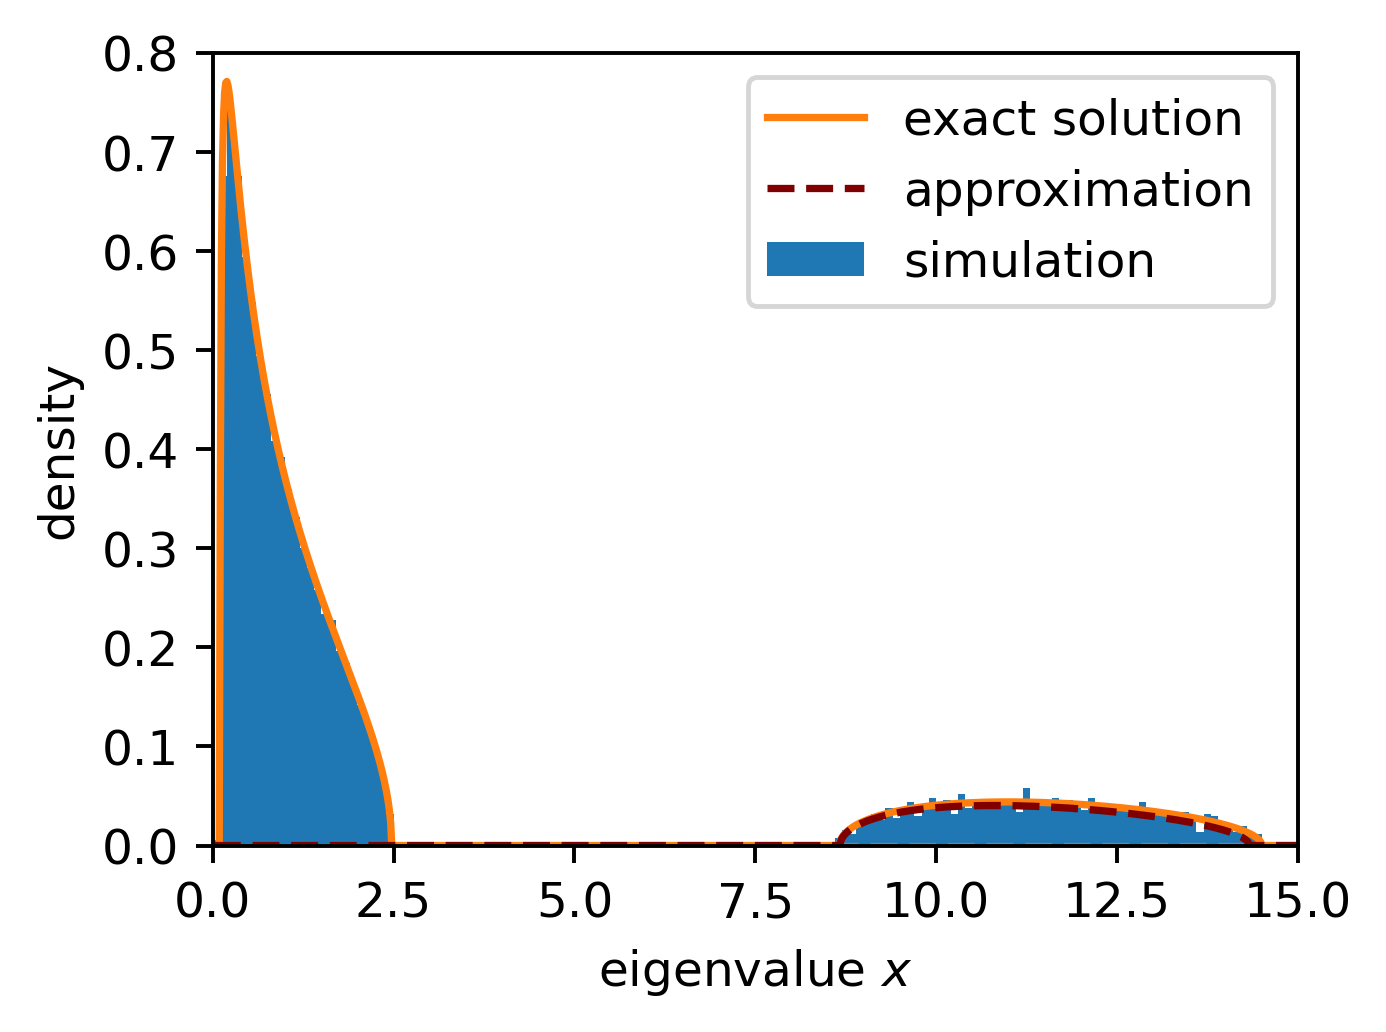

In [11]:
my_A = [1, 2, 10]
sigma = 1
rank_ratio = 0.2
theta = np.sqrt(10.) # np.sqrt(12)
x_max = theta**2 + 5
EV_axis = np.linspace(0, x_max, 10**3 + 1)[1::]

# Exact
Green_theo = [poly_solutions(*poly_constants(EV_axis + 1e-10 * 1j, sigma, my_A[i], rank_ratio, theta)) for i in range(len(my_A))]
PDF_theo = [PDF_from_Green(Green_theo[i]) for i in range(len(my_A))]
PDF_theo = [np.sum(np.maximum(0, PDF_theo[i]), axis=0) for i in range(len(my_A))]

# Approximation
large_PDF = [large_signal_PDF(EV_axis, sigma, my_A[i], rank_ratio, theta) for i in range(len(my_A))]


# Experiment
dim_q = 500
num_of_runs = 10
histo_q_collection = [0]*len(my_A)

for i, A in enumerate(my_A):
    signal_SVs = np.ones(int(rank_ratio * dim_q)) * theta
    
    start = time.time()
    exp_SV_q_collection = np.empty((num_of_runs, dim_q)) 
    var_samples_q = np.ones(dim_q)
    for j in range(num_of_runs):
        exp_SV_q_collection[j] = np.linalg.svd(get_matrix(dim_q, A, var_samples_q) + signal_matrix(dim_q, A, signal_SVs), compute_uv=False)
    end = time.time()
    print(f"Time for SV calculation (A = {A}, q = {dim_q}) =", end - start, "s")
    
    exp_EV_q_collection = exp_SV_q_collection.flatten()**2 # squaring gives eigenvalues of sample covariance matrix

    histo_q_collection[i] = np.histogram(exp_EV_q_collection, bins = np.linspace(0, x_max, 151), density=True) # bins = np.linspace(np.min(exp_EV_q_collection), np.max(exp_EV_q_collection), 10**2)
    

for i in [1]: # range(len(my_A))
    plt.figure(figsize=(4,3), dpi=350)
    plt.rcParams.update({'font.size': 10})
    plt.axhline(0, ls = "--", color = "grey")
    plt.bar(histo_q_collection[i][1][:-1:], histo_q_collection[i][0], color = my_colors_exp[0], align = "edge", width = np.diff(histo_q_collection[i][1]), label = r"simulation") # "center"
    plt.plot(EV_axis, PDF_theo[i], "-", color = my_colors_exp[i], label = "exact solution") # f"$A = {my_A[i]}$, exact"
    plt.plot(EV_axis, large_PDF[i], "--", color = my_colors_theo[i], label = "approximation")
    plt.xlim([0, x_max])
    plt.ylim([0, 0.8]) # 0.5 * rank_ratio**(1/2)
    plt.xlabel(r"eigenvalue $x$")
    plt.ylabel("density")
    plt.legend()
plt.show()

In [12]:
def general_recursion_Green_single(z, A, sigma, rank_ratio, theta, func, tolerance=10**(-6), loop_control=10**6, starting_value=1+1j, imag_eps=1e-10):
    """
    For a single value z (eigenvalue axis), determines the Green function value iteratively.
    """
    # Setting up the loop parameters
    n_loop = 0
    old_G = starting_value
    rel_error = tolerance + 1
    
    # Compute fixed-point equation until precision or upper bound on loops is reached.
    while rel_error > tolerance and n_loop < loop_control:
        new_G = func(G = old_G, z = z + imag_eps * 1j, sigma = sigma, A = A, rank_ratio = rank_ratio, theta = theta)
        rel_error = np.abs(1 - old_G / new_G) 
        old_G = new_G
        n_loop += 1
    
    # Return value of eigenvalue density with corresponding number of loops or precision error.
    return np.array([new_G, rel_error, n_loop]) 


# Green function for multiple EVs 

def general_recursion_Green(EV_values, A, sigma, rank_ratio, theta, func, tolerance=10**(-6), loop_control=10**6, starting_value=1+1j, imag_eps=1e-10):
    """
    Determine the Green function values iteratively for every value in EV_values.
    
    EV_values: array (eigenvalue variable)
    k: scalar (lower power law bound)
    K: scalar (upper power law bound)
    A: scalar (dimension ratio)
    tolerance: scalar (precision of resulting value of spectral density)
    loop_control: scalar (upper bound on number of loops)
    starting_value: imag. scalar (first value of Green function 'm' to start loop with)
    imag_eps: scalar (small control parameter for convergence)
    
    output: array (Green function values)
    """
    # Depending on amount of 'z_values', determining the spectral density's values 'dist_values' is time consuming.
    time_start = time.time()
    dist_values = np.array([general_recursion_Green_single(_, A, sigma, rank_ratio, theta, func, tolerance=tolerance, starting_value=starting_value, imag_eps=imag_eps) for _ in EV_values])
    time_end = time.time()
    print(f"Runtime for Green function (A = {A}):", np.rint(time_end - time_start), "seconds")
    
    # Only return values themselves, not the error they come with. Can be easily changed by slicing.
    return dist_values[:, 0] 


def MP_fixed_point_general(G, z, sigma, A, rank_ratio, theta):
    """
    Computes the right-hand side of the self-consistency equation with a few degenerate signal eigenvalues (other than outliers there is a Marchenko-Pastur law).
    """
    # instead of integration: discrete signals with corresponding multiplicities counted as percentage of full rank (r/q)
    theta = np.array(theta)
    rank_ratio = np.array(rank_ratio)

    theta = np.concatenate((theta, np.zeros(1)))
    rank_ratio = np.concatenate((rank_ratio, np.ones(1) * (1 - np.sum(rank_ratio))))
   
    res = (z * (1 - sigma**2 / A * G) - sigma**2 * (1 - 1/A) - theta**2 / (1 - sigma**2 / A * G))**(-1)
    
    return np.sum(rank_ratio * res, axis = 0)

[ 5.  9. 10. 14. 20.] [0.002 0.002 0.002 0.002 0.002]
Runtime for Green function (A = 1): 114.0 seconds
Runtime for Green function (A = 2): 117.0 seconds
Runtime for Green function (A = 10): 288.0 seconds
Time for SV calculation (A = 1, q = 500) = 10.054311752319336 s
Time for SV calculation (A = 2, q = 500) = 16.024438619613647 s
Time for SV calculation (A = 10, q = 500) = 29.96089506149292 s


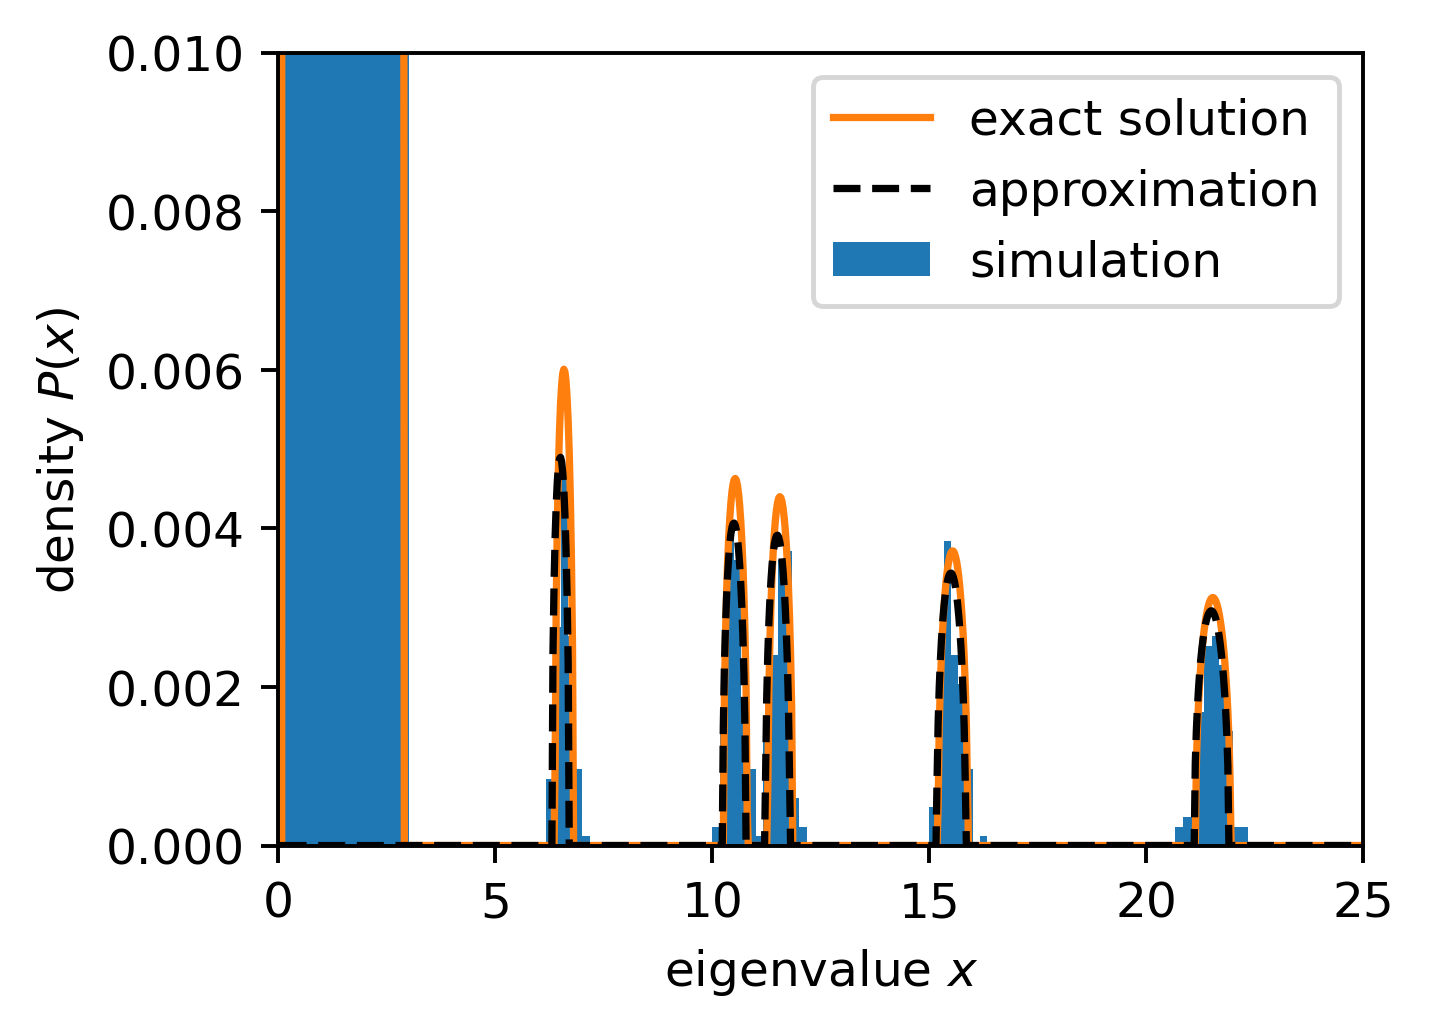

In [13]:
# ETA = 10 min

sigma = 1
my_A = [1, 2, 10] 
all_thetas =  np.sqrt([5, 9, 10, 14, 20])
num_signals = len(all_thetas) 
dim_q = 500
rank_ratio = num_signals / dim_q # total rank ratio
all_rank_ratios = np.ones(num_signals) / dim_q # rank ratio for each signal (here all the same)
x_max = max(all_thetas**2) + 5
EV_axis = np.linspace(0, x_max, 10**3 + 1)[1::]

print(all_thetas**2, all_rank_ratios)

# Exact
Green_rec = [general_recursion_Green(EV_axis, A, sigma, all_rank_ratios, all_thetas, MP_fixed_point_general, imag_eps = 0) for A in my_A]
PDF_rec = [PDF_from_Green(_, make_positive = True) for _ in Green_rec]

# Approximation (for each signal theta)
large_PDF = [[large_signal_PDF(EV_axis, sigma, my_A[i], rank_ratio, theta) for rank_ratio, theta in zip(all_rank_ratios, all_thetas)] for i in range(len(my_A))]
large_PDF = [np.sum(np.array(large_PDF[i]), axis = 0) for i in range(len(my_A))]




# Experiment
# Plot histogram of eigenvalues of the random matrix and compare with theory prediction (for each dimension ratio in "my_A").
num_of_runs = 100
histo_q_collection = [0]*len(my_A)

multiplicity = int(rank_ratio / num_signals * dim_q)
theta_values_with_multiplicity = np.array([[all_thetas[i]] * multiplicity for i in range(len(all_thetas))]).flatten()


for i, A in enumerate(my_A):
    signal_SVs = theta_values_with_multiplicity
    
    start = time.time()
    exp_SV_q_collection = np.empty((num_of_runs, dim_q)) 
    var_samples_q = np.ones(dim_q)
    for j in range(num_of_runs):
        exp_SV_q_collection[j] = np.linalg.svd(get_matrix(dim_q, A, var_samples_q) + signal_matrix(dim_q, A, signal_SVs), compute_uv=False)
    end = time.time()
    print(f"Time for SV calculation (A = {A}, q = {dim_q}) =", end - start, "s")
    
    exp_EV_q_collection = exp_SV_q_collection.flatten()**2 # squaring gives eigenvalues of sample covariance matrix

    histo_q_collection[i] = np.histogram(exp_EV_q_collection, bins = np.linspace(0, x_max, 151), density=True) # bins = np.linspace(np.min(exp_EV_q_collection), np.max(exp_EV_q_collection), 10**2)
    
    
    
    
# plot
    
for i in [1]: # in range(len(my_A))
    plt.figure(figsize=(4,3), dpi=350)
    
    plt.bar(histo_q_collection[i][1][:-1:], histo_q_collection[i][0], color = my_colors_exp[0], align = "edge", width = np.diff(histo_q_collection[i][1]), label = r"simulation") # align = "center"
    plt.plot(EV_axis, PDF_rec[i], "-", color = my_colors_exp[i], label = r"exact solution")
    plt.plot(EV_axis, large_PDF[i], "--", color = "black", label = r"approximation")

    plt.xlim([0, x_max])
    plt.ylim([0, 0.5 * rank_ratio**(1/2) / 5])
    plt.xlabel(r"eigenvalue $x$")
    plt.ylabel(r"density $P(x)$")
    plt.xscale("linear")
    plt.yscale("linear")
#     plt.title(f"$A = {my_A[i]}$")
    plt.legend()
plt.show()

Power Law Signal Distribution

In [12]:
# Power Law Samples

def inv_cum_sum(y, k, K):
    """
    Calculates the functional inverse of the cumulative density function of a power law probability density with exponent -2.
    
    y: array (y-axis values in interval [0, 1])
    k: scalar (lower power law bound)
    K: scalar (upper power law bound) 
    
    output: array (x-axis values in interval [k, K], functional inverse of CDF)
    """
    return (1/k - y*(1/k - 1/K))**(-1)

def get_power2_samples(num, k, K):
    """
    Retrieves a finite set of samples from a power law probability density with exponent -2.
    
    num: scalar (number of points on x-axis)
    k: scalar (lower power law bound)
    K: scalar (upper power law bound) 
    
    output: array (x-axis values in interval [k, K], functional inverse of CDF)
    """
    return inv_cum_sum(np.linspace(0, 1, int(num)), k, K)


# Recursion function for a single EV z

def general_recursion_Green_single(z, sigma, A, func, tolerance=10**(-6), loop_control=10**6, starting_value=1+1j, imag_eps=1e-10, **kwargs):
    """
    Iterative solution of some fixed-point equation for a single value z.
    """
    # Setting up the loop parameters
    n_loop = 0
    old_G = starting_value
    rel_error = tolerance + 1
    
    # Compute fixed-point equation until precision or upper bound on loops is reached.
    while rel_error > tolerance and n_loop < loop_control:
        new_G = func(G = old_G, z = z + imag_eps * 1j, sigma = sigma, A = A, **kwargs)
        rel_error = np.abs(1 - old_G / new_G) 
        old_G = new_G
        n_loop += 1
    
    # Return value of eigenvalue density with corresponding number of loops or precision error.
    return np.array([new_G, rel_error, n_loop]) 


def fixed_point_rhs_power_signal(G, z, sigma, A, k, K):
    """
    Right-hand side of the fixed-point equation for i.i.d. noise and power law distributed signals (exponent -2).
    """
    factor = (1 - sigma**2 / A * G)
    C = factor * ( z * factor - sigma**2 * (1 - 1/A) )
    rhs = factor / C**2 * (1/k - 1/K)**(-1) * np.log((1 - C / k) / (1 - C / K)) + factor / C
    
    return rhs
    


# Green function for multiple EVs 

def general_recursion_Green(EV_values, sigma, A, func, tolerance=10**(-6), loop_control=10**6, starting_value=1+1j, imag_eps=1e-10, **kwargs):
    """
    Iterative solution of some fixed-point equation for all parameter values in EV_values.
    
    EV_values: array (eigenvalue variable)
    sigma: variance
    A: scalar (dimension ratio)
    func: function of right-hand side in fixed-point equation
    tolerance: scalar (precision of resulting value of spectral density)
    loop_control: scalar (upper bound on number of loops)
    starting_value: imag. scalar (first value of Green function 'm' to start loop with)
    imag_eps: scalar (small control parameter for convergence)
    
    output: array (Green function values)
    """
    # Depending on amount of 'z_values', determining the spectral density's values 'dist_values' is time consuming.
    time_start = time.time()
    dist_values = np.array([general_recursion_Green_single(_, sigma, A, func, tolerance=tolerance, starting_value=starting_value, imag_eps=imag_eps, **kwargs) for _ in EV_values])
    time_end = time.time()
    print(f"Runtime for Green function (A = {A}):", np.rint(time_end - time_start), "seconds")
    
    # Only return values themselves, not the error they come with. Can be easily changed by slicing.
    return dist_values[:, 0] 

Runtime for Green function (A = 1): 0.0 seconds
Runtime for Green function (A = 2): 0.0 seconds
Runtime for Green function (A = 10): 0.0 seconds


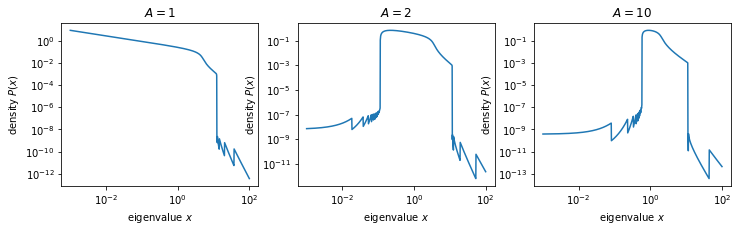

In [13]:
sigma = 1
my_A = [1, 2, 10]
k = 1e-1
K = 1e+1

# EV_axis = np.linspace(0, 40, 10**3 + 1)[1::]
EV_axis = np.logspace(-3, 2, 10**3 + 1)[1::]

Green_vals_upper = [general_recursion_Green(EV_axis, sigma, A, fixed_point_rhs_power_signal, tolerance=1e-6, imag_eps=0, k = k, K = K) for A in my_A]
PDF_upper = [PDF_from_Green(Green_vals_upper[i], make_positive = True) for i in range(len(my_A))]


fig, axs = plt.subplots(1, 3, figsize = (12,3))

axs[0].plot(EV_axis, PDF_upper[0])
axs[1].plot(EV_axis, PDF_upper[1])
axs[2].plot(EV_axis, PDF_upper[2])

for i in range(3):
    axs[i].set_xscale("log")
    axs[i].set_yscale("log")
    axs[i].set_title(f"$A = {my_A[i]}$")
    axs[i].set_xlabel("eigenvalue $x$")
    axs[i].set_ylabel("density $P(x)$")
plt.show()

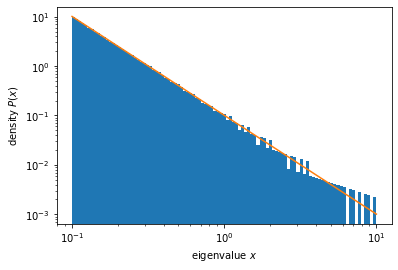

In [14]:
# Numerical Simulations

# 1. Get power law samples (signal values alias eigenvalues)

dim_q = 1000
signal_samples = get_power2_samples(dim_q, k, K)
signal_axis = np.logspace(np.log10(k), np.log10(K), 10)

plt.hist(signal_samples, bins=np.logspace(np.log10(np.min(signal_samples)), np.log10(np.max(signal_samples)), 100), density=True, log=True)
plt.plot(signal_axis, signal_axis**(-2) / (1/k - 1/K))
plt.xlabel("eigenvalue $x$")
plt.ylabel("density $P(x)$")
plt.xscale("log")
plt.yscale("log")
plt.show()

ETA: 1 min
Time for SV calculation (A = 1, q = 1000) = 4.104136943817139 s
Time for SV calculation (A = 2, q = 1000) = 5.847104072570801 s
Time for SV calculation (A = 10, q = 1000) = 11.388118743896484 s


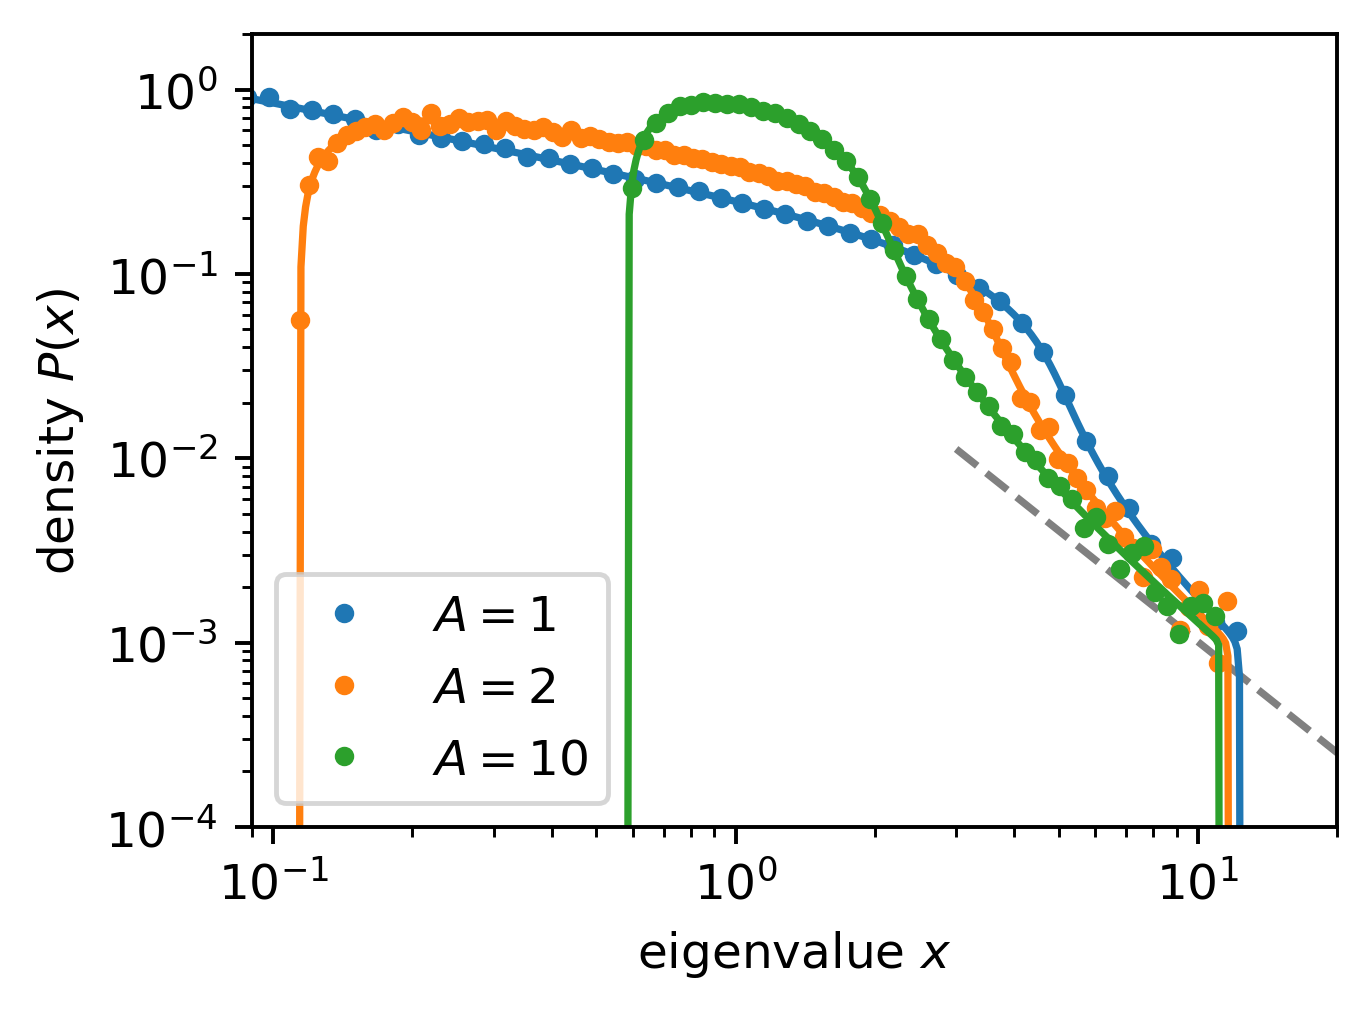

In [9]:
# 2. Get matrix and determine SVs (for EV density)

dim_q = 1000
num_of_runs = 10

print("ETA: 1 min")
plt.figure(figsize=(4,3), dpi=350)
plt.plot(np.logspace(np.log10(3), 2, 10), np.logspace(np.log10(3), 2, 10)**(-2) / (1/k - 1/K), "--", color = "grey")

variances = sigma**2 * np.ones(dim_q)
signal_SV_samples = np.sqrt(get_power2_samples(dim_q, k, K)) # (singular values for SVD)
bin_numbers = [201, 101, 51]

histo_q_collection = [0]*len(my_A)
for j in range(len(my_A)):
    start = time.time()
    exp_SV_q_collection = np.empty((num_of_runs, dim_q))
    
    for i in range(num_of_runs):
        exp_SV_q_collection[i] = np.linalg.svd(get_matrix(dim_q, my_A[j], variances) + signal_matrix(dim_q, my_A[j], signal_SV_samples), compute_uv=False)
    end = time.time()
    print(f"Time for SV calculation (A = {my_A[j]}, q = {dim_q}) =", end - start, "s")
    
    exp_EV_q_collection = exp_SV_q_collection.flatten()**2 # squaring gives eigenvalues of sample covariance matrix

    histo_q_collection[j] = np.histogram(exp_EV_q_collection, bins = np.logspace(np.log10(np.min(exp_EV_q_collection)), np.log10(np.max(exp_EV_q_collection)), bin_numbers[j]), density=True)
    
    
for j in range(len(my_A)):
    plt.plot(histo_q_collection[j][1][1::] - np.diff(histo_q_collection[j][1]) /2, histo_q_collection[j][0], ".", linewidth = 4, label = f"$A = {my_A[j]}$")
    plt.plot(EV_axis, PDF_upper[j], color = my_colors_exp[j])   

    

plt.xlim([9e-2, 2e+1])
plt.ylim([1e-4, 2e+0])
plt.xlabel(r"eigenvalue $x$")
plt.ylabel(r"density $P(x)$")
plt.xscale("log")
plt.yscale("log")
plt.legend(loc = "lower left")
plt.show()